Write a function in R that takes parameters N0 and tmax as input and returns
the number of individuals in the population after tmax generations, starting
with N0 individuals. (1p)

In [ ]:

population <- function(N0, tmax) {
  total_pop <- N0
  for (t in 1:tmax) { 
    total_pop <- rpois(total_pop, 1)
    total_pop <- sum(total_pop)

  }

  return(total_pop)
  
}


Write another function that takes N0 and tmax as input parameters and calls
the function from a) repeatedly (1000 times) to calculate the risk of extinction
within tmax generations, starting with N0 individuals. (1p)

In [33]:
population <- function(N0, tmax) {
  total_pop <- N0
  for (t in 1:tmax) { 
    total_pop <- rpois(total_pop, 1)
    total_pop <- sum(total_pop)

  }

  return(total_pop)
  
}


extinction <- function(N0, tmax) {
  extinction_vec <- numeric(1000)
  for (i in 1:1000) {
    extinction_vec[i] <- population(N0, tmax)
  }
  no_of_zeros <- sum(extinction_vec == 0)
  prob_extinction <- (no_of_zeros/1000) *100

  return(paste(no_of_zeros, "extinction events and" , prob_extinction, "% probability of extinction in 1000 simulations."))

  #return(sum(extinction_vec == 0))


}


print(extinction(5, 5))

[1] "201 extinction events and 20.1 % probability of extinction in 1000 simulations."


Finally, write a script that uses the function from b) to plot the risk of
extinction within 100 generations as a function of N0, with N0 taking the
values 10, 20, 30, … 100. (1p)

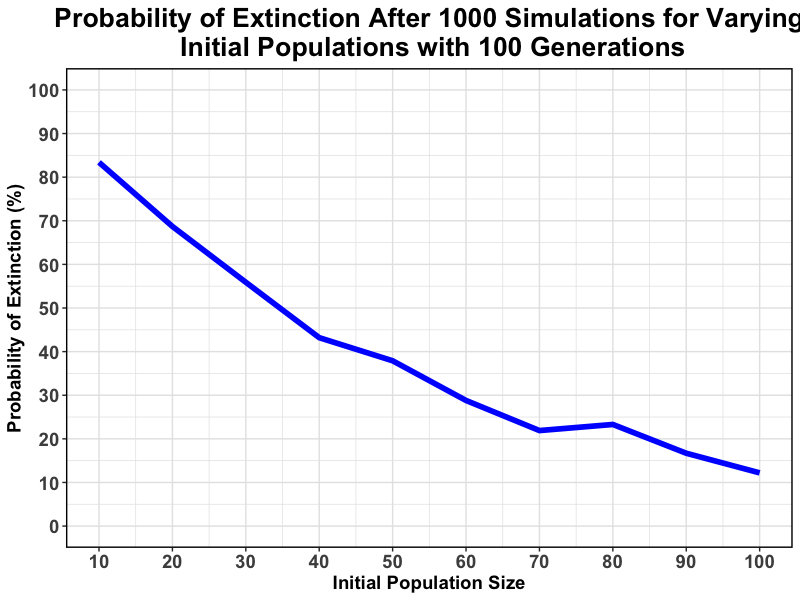

In [14]:
#install.packages("ggplot2")
#library(ggplot2)


population <- function(N0, tmax) {
  total_pop <- N0
  for (t in 1:tmax) { 
    total_pop <- rpois(total_pop, 1)
    total_pop <- sum(total_pop)

  }

  return(total_pop)
  
}


extinction <- function(N0, tmax) {
  extinction_vec <- numeric(1000)
  for (i in 1:1000) {
    extinction_vec[i] <- population(N0, tmax)
  }
  no_of_zeros <- sum(extinction_vec == 0)
  prob_extinction <- (no_of_zeros/1000) *100
  
  return(prob_extinction)

}


N0_ex <- seq(10, 100, by = 10)

risk_100 <- function(N0) {
  risk_df <- data.frame(
    N0s = numeric(length(N0)),
    prob = numeric(length(N0))
  )

  for (i in seq_along(N0)) {
    risk_df$N0s[i] <- N0[i]
    risk_df$prob[i] <- extinction(N0[i], 100) 
  }

  plot <- ggplot(data = risk_df, aes(x = N0s, y = prob)) +
    geom_line(color = "blue", linewidth = 2) +
    scale_y_continuous(limits = c(100,0), # y - axis limits
                    breaks = seq(0,100, by = 10)) + # adjusting y axis spacing and tick marks
    scale_x_continuous(limits = c(100,10), # y - axis limits
                    breaks = seq(10,100, by = 10)) + # adjusting x axis spacing and tick marks
    labs(   # adding labels
    title = ("Probability of Extinction After 1000 Simulations for Varying\n Initial Populations with 100 Generations"),
    y = ("Probability of Extinction (%)"),
    x = ("Initial Population Size")
    ) +
    theme( # adjusting aesthetics 
      panel.background = element_rect(fill = "white"),
      panel.grid.major = element_line(color = "grey90"),
      panel.grid.minor = element_line(color = "grey90"),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
      plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
      axis.title.x = element_text(size = 14, face = "bold"), 
      axis.title.y = element_text(size = 14, face = "bold"), 
      axis.text.x = element_text(size = 14, face = "bold"),
      axis.text.y = element_text(size = 14, face = "bold"))

  return(plot)

}

print(risk_100(N0_ex))

